# Notebook Analytics — DA-R3 · AnatoQuizUp 2026.1

**Dashboard Gerencial e Analítico da Release 3 (final)** — panorama completo do semestre nos três eixos da disciplina:

| Eixo | Modelo teórico | Fonte de dados |
|------|----------------|----------------|
| **Produto** | Q-Rapids / MeasureSoftGram — densidades normalizadas [0–1] com pesos do [Plano de Qualidade](https://fga-eps-mds.github.io/2026-1-AnatoQuizUp-Doc/qualidade/qualidade/) | SonarCloud (medidas por arquivo, atuais e históricas), GitHub Actions |
| **Processo** | Kanban — CFD, lead/cycle time, throughput e limites WIP pela **Lei de Little** (WIP = TP × LT, Brechner) | ZenHub (eventos reais de movimentação do board), GitHub |
| **Projeto** | **AgileEVM** (Sulaiman, Barton & Blackburn, 2006) cumulativo, com correção metodológica sobre as releases anteriores | Relatórios de sprint publicados, ZenHub, Plano de Custos |

**Reprodutibilidade:** os dados brutos estão versionados em `DA-R3/dados/` e foram extraídos pelos scripts de `DA-R3/scripts/` (ZenHub GraphQL + REST, GitHub REST, SonarCloud). Os dashboards interativos publicados no GitHub Pages consomem o mesmo `dados-consolidados.json` gerado por `consolidar.mjs` — notebook e dashboards contam a mesma história a partir da mesma base.

> Coleta de referência: **12/06/2026** (Sprint 8 em andamento; sprints fechadas S1–S7).

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd

DADOS = Path("dados")
consolidado = json.loads((DADOS / "dados-consolidados.json").read_text(encoding="utf-8"))
sonar_arquivos = json.loads((DADOS / "sonarcloud-arquivos.json").read_text(encoding="utf-8"))
zenhub_issues = json.loads((DADOS / "zenhub-issues.json").read_text(encoding="utf-8"))

VERDE, AMARELO, VERMELHO, AZUL = "#2e7d32", "#f9a825", "#c62828", "#3f51b5"
plt.rcParams["figure.figsize"] = (11, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

print("Gerado em:", consolidado["geradoEm"])
print("Premissas registradas:", len(consolidado["premissas"]))

Gerado em: 2026-06-15T02:26:21.715Z
Premissas registradas: 10


## 1. Eixo Produto — normalização das métricas (Q-Rapids)

O modelo Q-Rapids transforma métricas brutas do SonarCloud em **densidades normalizadas [0–1]**: a fração dos arquivos de produção que está dentro da faixa ideal definida no Plano de Qualidade. A normalização por arquivo (e não pela média do projeto) evita que poucos arquivos muito bons mascarem muitos arquivos ruins.

| Fator | Faixa ideal (por arquivo) | Peso |
|-------|---------------------------|------|
| Complexidade | ciclomática/função ≤ 10 | 35% |
| Comentários | 10%–30% de linhas comentadas | 10% |
| Duplicação | < 5% de linhas duplicadas | 25% |
| Cobertura | ≥ 85% | 30% |

**Qualidade do Produto** = média ponderada das quatro densidades. A célula abaixo recalcula as densidades a partir das medidas por arquivo (`component_tree` do SonarCloud), demonstrando o método.

In [2]:
REPO_CURTO = {
    "fga-eps-mds_2026-1-AnatoQuizUp-Usuario-Service": "Usuario-Service",
    "fga-eps-mds_2026-1-AnatoQuizUp-Quiz-Service": "Quiz-Service",
    "fga-eps-mds_2026-1-AnatoQuizUp-BFF": "BFF",
    "fga-eps-mds_2026-1-AnatoQuizUp-Web": "Web",
}
PESOS = {"complexidade": 0.35, "comentarios": 0.10, "duplicacao": 0.25, "cobertura": 0.30}

def densidades(arquivos: list[dict]) -> dict:
    df = pd.DataFrame([{**a["medidas"], "caminho": a["caminho"]} for a in arquivos])
    df = df[df.get("ncloc", pd.Series(dtype=float)).fillna(0) > 0]
    com_funcoes = df[df["functions"].fillna(0) > 0]
    com_cobertura = df[df["coverage"].notna()] if "coverage" in df else df.iloc[0:0]
    return {
        "complexidade": (com_funcoes["complexity"] / com_funcoes["functions"] <= 10).mean(),
        "comentarios": df["comment_lines_density"].fillna(0).between(10, 30).mean(),
        "duplicacao": (df["duplicated_lines_density"].fillna(0) < 5).mean(),
        "cobertura": (com_cobertura["coverage"] >= 85).mean() if len(com_cobertura) else float("nan"),
        "arquivos": len(df),
    }

linhas = []
for chave, arquivos in sonar_arquivos["projetos"].items():
    d = densidades(arquivos)
    d["qualidade_produto"] = sum(d[f] * p for f, p in PESOS.items())
    linhas.append({"repositorio": REPO_CURTO[chave], **d})

dens_df = pd.DataFrame(linhas).set_index("repositorio").round(3)
dens_df

,complexidade,comentarios,duplicacao,cobertura,arquivos,qualidade_produto
repositorio,,,,,,
Usuario-Service,1.000,0.020,0.980,0.920,102,0.873
Quiz-Service,1.000,0.012,1.000,0.731,82,0.820
BFF,1.000,0.000,1.000,0.926,29,0.878
Web,0.989,0.007,0.986,0.912,139,0.867


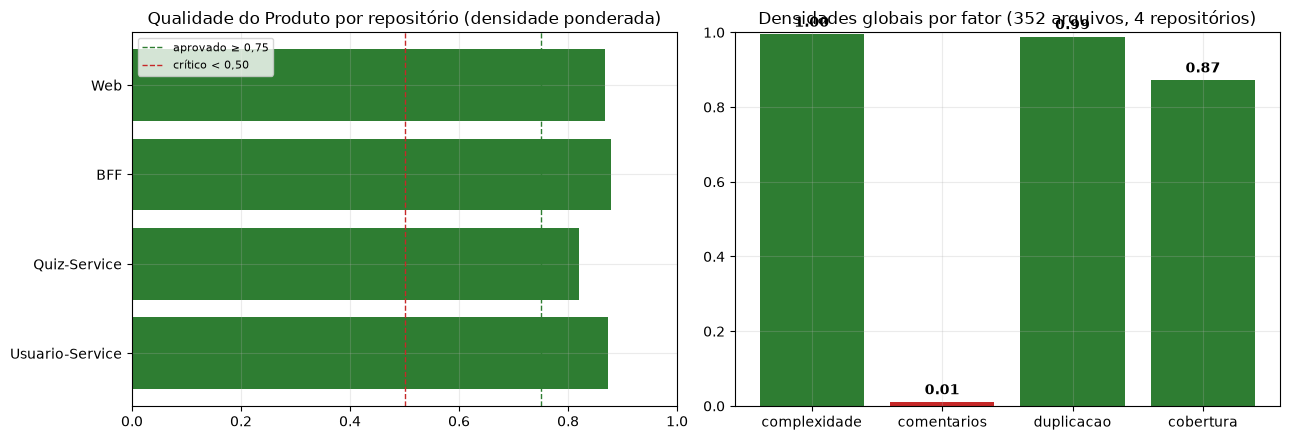

Indicadores estratégicos — Qualidade do Produto: 0.86 | Bloqueios: 0.98 | Prontidão: 0.68


In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

cores = [VERDE if v >= 0.75 else AMARELO if v >= 0.5 else VERMELHO for v in dens_df["qualidade_produto"]]
ax1.barh(dens_df.index, dens_df["qualidade_produto"], color=cores)
ax1.axvline(0.75, color=VERDE, ls="--", lw=1, label="aprovado ≥ 0,75")
ax1.axvline(0.50, color=VERMELHO, ls="--", lw=1, label="crítico < 0,50")
ax1.set_xlim(0, 1); ax1.set_title("Qualidade do Produto por repositório (densidade ponderada)"); ax1.legend(fontsize=8)

fatores = ["complexidade", "comentarios", "duplicacao", "cobertura"]
global_dens = consolidado["produto"]["global"]["densidades"]
vals = [global_dens[f] for f in fatores]
ax2.bar(fatores, vals, color=[VERDE if v >= 0.75 else AMARELO if v >= 0.5 else VERMELHO for v in vals])
ax2.set_ylim(0, 1); ax2.set_title("Densidades globais por fator (352 arquivos, 4 repositórios)")
for i, v in enumerate(vals):
    ax2.text(i, v + 0.02, f"{v:.2f}", ha="center", fontweight="bold")
plt.tight_layout(); plt.show()

ind = consolidado["produto"]["indicadores"]
print(f"Indicadores estratégicos — Qualidade do Produto: {ind['qualidadeProduto']:.2f} | "
      f"Bloqueios: {ind['bloqueios']:.2f} | Prontidão: {ind['prontidao']:.2f}")

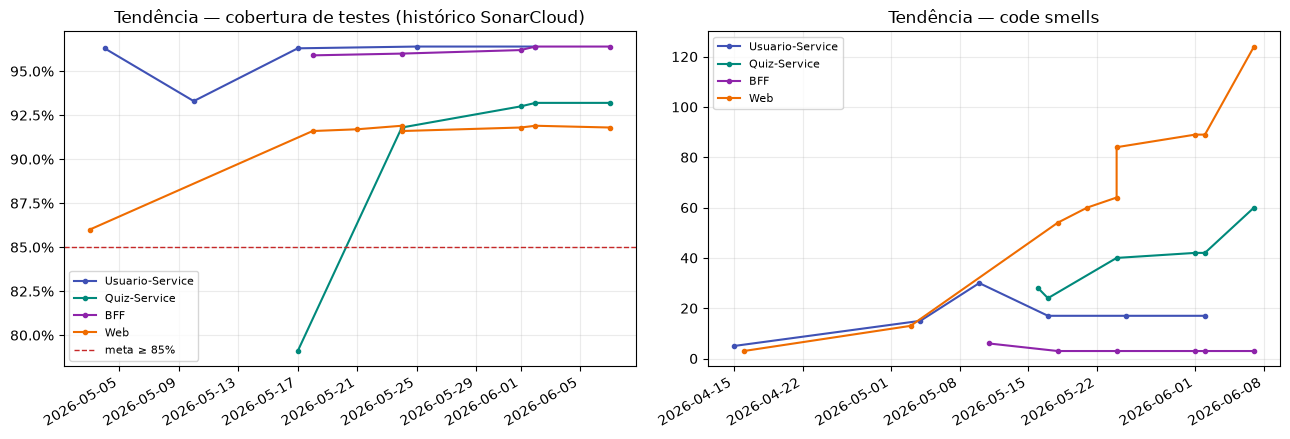

In [4]:
historico = consolidado["produto"]["historico"]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
CORES_REPO = {"Usuario-Service": AZUL, "Quiz-Service": "#00897b", "BFF": "#8e24aa", "Web": "#ef6c00"}
for repo, series in historico.items():
    if series.get("coverage"):
        s = pd.DataFrame(series["coverage"]).assign(data=lambda d: pd.to_datetime(d["data"]))
        ax1.plot(s["data"], s["valor"], marker="o", ms=3, label=repo, color=CORES_REPO[repo])
    if series.get("code_smells"):
        s = pd.DataFrame(series["code_smells"]).assign(data=lambda d: pd.to_datetime(d["data"]))
        ax2.plot(s["data"], s["valor"], marker="o", ms=3, label=repo, color=CORES_REPO[repo])
ax1.axhline(85, color=VERMELHO, ls="--", lw=1, label="meta ≥ 85%")
ax1.set_title("Tendência — cobertura de testes (histórico SonarCloud)"); ax1.legend(fontsize=8)
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
ax2.set_title("Tendência — code smells"); ax2.legend(fontsize=8)
fig.autofmt_xdate(); plt.tight_layout(); plt.show()

### Interpretação — Produto

- **Qualidade do Produto global = 0,86 (verde)**. Complexidade (1,00) e duplicação (0,99) praticamente ideais; cobertura por arquivo 0,87 — consequência direta do *quality gate* de 85% no CI, decisão tomada na R1.
- **Comentários é o fator vermelho (≈ 0,01)**: o time praticamente não comenta código. Com peso 10%, o impacto no índice é limitado, mas o fator merece discussão: a convenção do projeto privilegia código autoexplicativo em PT-BR — o time **aceita conscientemente** este vermelho e registra a justificativa, em vez de inflar comentários para "ganhar nota" (gaming da métrica).
- **Prontidão (0,68, amarelo)** é puxada por builds quebradas em PRs de feature — o gate de cobertura bloqueando merge funciona como projetado, mas o time deve quebrar menos a pipeline *antes* do merge (ver decisão D5).
- **Cobertura do Quiz-Service** é a mais baixa entre os repositórios na coleta — concentrou as features mais recentes (quiz, listas, dashboards). Ver decisão D4.

## 2. Eixo Processo — fluxo Kanban e Lei de Little

A linha do tempo de cada issue foi **reconstruída dos eventos reais `transferIssue`** do ZenHub (126 issues com histórico de movimentação), o que permite medir lead time, cycle time e tempo por etapa sem depender de registro manual.

Definições (cap. 2 do livro da disciplina):
- **Lead time** = criação → fechamento.
- **Cycle time** = 1ª entrada em *In Progress* → fechamento.
- **Fluxo de código** = issues que passaram por *In Progress* (separa trabalho de engenharia de issues administrativas — inclusive as fechadas em lote na limpeza de board de 12/06, que distorceriam as medianas).
- **Lei de Little**: WIP = TP × LT — usada *prescritivamente* para calcular os limites WIP que o quadro deveria adotar.

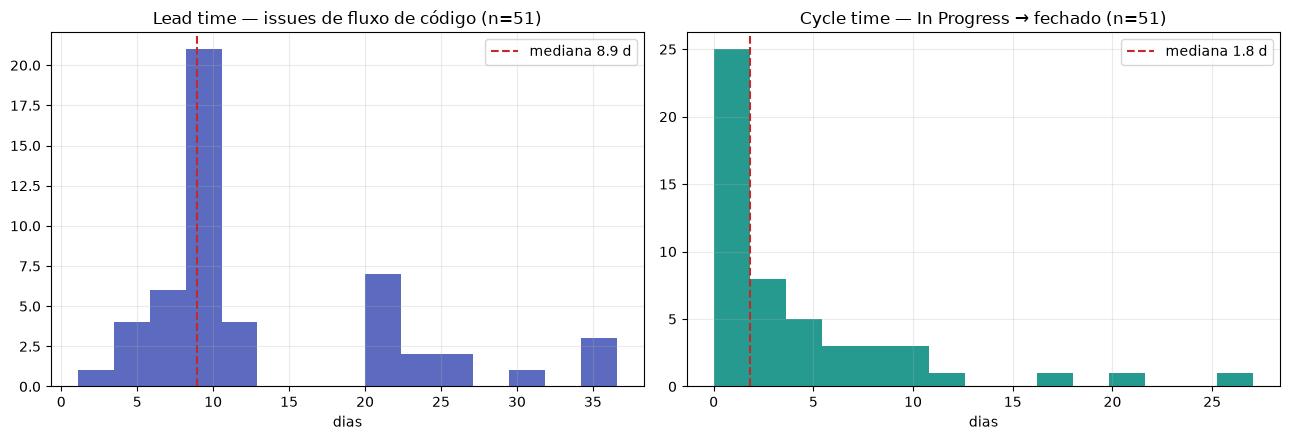

Lead time:  mediana 8.91 d · média 13.31 d
Cycle time: mediana 1.84 d · média 4.12 d


In [5]:
P = consolidado["processo"]

lead = pd.DataFrame(P["leadTime"]["pontos"])
fluxo = lead[lead["fluxo"]]
cycle = pd.DataFrame(P["cycleTime"]["pontos"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
ax1.hist(fluxo["dias"], bins=15, color=AZUL, alpha=0.85)
ax1.axvline(fluxo["dias"].median(), color=VERMELHO, ls="--", label=f"mediana {fluxo['dias'].median():.1f} d")
ax1.set_title(f"Lead time — issues de fluxo de código (n={len(fluxo)})"); ax1.set_xlabel("dias"); ax1.legend()
ax2.hist(cycle["dias"], bins=15, color="#00897b", alpha=0.85)
ax2.axvline(cycle["dias"].median(), color=VERMELHO, ls="--", label=f"mediana {cycle['dias'].median():.1f} d")
ax2.set_title(f"Cycle time — In Progress → fechado (n={len(cycle)})"); ax2.set_xlabel("dias"); ax2.legend()
plt.tight_layout(); plt.show()

print(f"Lead time:  mediana {P['leadTime']['fluxoDeCodigo']['medianaDias']} d · média {P['leadTime']['fluxoDeCodigo']['mediaDias']} d")
print(f"Cycle time: mediana {P['cycleTime']['medianaDias']} d · média {P['cycleTime']['mediaDias']} d")

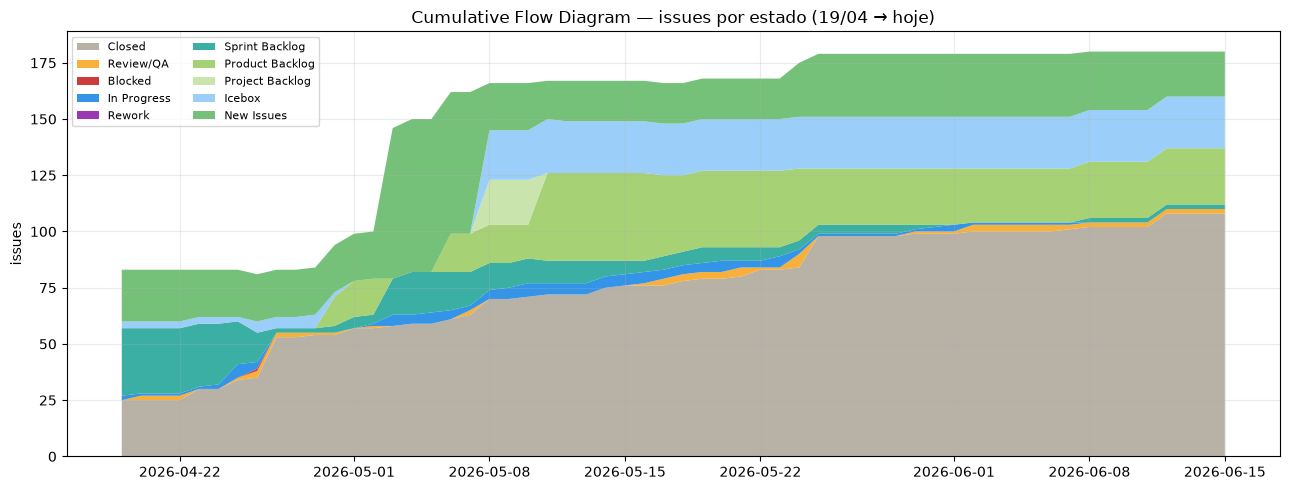

In [6]:
cfd = pd.DataFrame(P["cfd"]).set_index("data")
cfd.index = pd.to_datetime(cfd.index)
ordem = ["Closed", "Review/QA", "Blocked", "In Progress", "Rework", "Sprint Backlog",
         "Product Backlog", "Project Backlog", "Icebox", "New Issues"]
cores_cfd = ["#b0a99c", "#f9a825", "#c62828", "#1e88e5", "#8e24aa", "#26a69a",
             "#9ccc65", "#c5e1a5", "#90caf9", "#66bb6a"]
fig, ax = plt.subplots(figsize=(13, 5))
ax.stackplot(cfd.index, [cfd[c] for c in ordem], labels=ordem, colors=cores_cfd, alpha=0.9)
ax.legend(loc="upper left", fontsize=8, ncol=2)
ax.set_title("Cumulative Flow Diagram — issues por estado (19/04 → hoje)")
ax.set_ylabel("issues")
plt.tight_layout(); plt.show()

In [7]:
little = P["leiDeLittle"]
wip_atual = P["wipAtual"]
tabela_little = pd.DataFrame([
    {
        "etapa": etapa,
        "LT médio (dias)": v["ltMedioDias"],
        "WIP = TP×LT": v["wipCalculado"],
        "WIP c/ margem 50% (Brechner)": v["wipComMargem50"],
        "WIP atual": wip_atual.get(etapa, 0),
    }
    for etapa, v in little["etapas"].items()
])
print(f"TP (etapa gargalo, últimas 4 semanas) = {little['tpDiaUtil']} issues/dia útil")
tabela_little

TP (etapa gargalo, últimas 4 semanas) = 0.75 issues/dia útil


,etapa,LT médio (dias),WIP = TP×LT,WIP c/ margem 50% (Brechner),WIP atual
0,Sprint Backlog,6.94,6,8,2
1,In Progress,2.58,2,3,0
2,Review/QA,1.42,2,2,2


### Interpretação — Processo

- **Cycle time mediano de ~1,8 dia** com **lead time mediano de ~8,9 dias**: o tempo de execução é curto; a espera está **antes** do desenvolvimento (Sprint Backlog, LT médio ≈ 7 dias). O gargalo do fluxo não é codificar nem revisar — é a fila de entrada.
- **Limites WIP pela Lei de Little**: com TP ≈ 0,75 issue/dia útil, os limites recomendados são **Sprint Backlog ≤ 8, In Progress ≤ 3, Review/QA ≤ 2** (margem de 50% de Brechner). O quadro hoje opera dentro desses limites — o problema do semestre não foi sobrecarga de WIP, e sim **vazão planejada acima da capacidade** (ver Eixo Projeto).
- O CFD mostra a banda *Closed* crescendo de forma aproximadamente linear de maio em diante (ritmo estável) e o degrau de 12/06 corresponde à limpeza de board (fechamento administrativo em lote), tratado separadamente nas medianas.
- **Code review time mediano < 1 dia** — saudável e compatível com o benchmark do exemplo da disciplina.

## 3. Eixo Projeto — AgileEVM com correção metodológica

**O que estava errado nos EVMs das releases anteriores:** o cálculo era feito **por sprint isolada**, com `PV = BAC da sprint` e `AC = BAC da sprint` (o orçamento inteiro era dado como consumido). Consequências: **SPI ≡ CPI** sempre (o índice de custo não trazia informação nova), nenhuma visão acumulada e nenhuma projeção de término (EAC) possível — exatamente os pontos apontados pelo professor.

**Modelo corrigido — EVM ágil em story points (mesmo enquadramento do exemplo da disciplina), com custo em R$ para o CPI:**

| Grandeza | Definição | Fonte no nosso projeto |
|----------|-----------|------------------------|
| **PV (SP)** | Σ story points **planejados** acumulados | escopo planejado por sprint: relatórios publicados (S1–S4); ZenHub medido (S5+) |
| **EV (SP)** | Σ story points **entregues** acumulados | fechamentos com estimate por janela de sprint |
| **SPI** | `EV(SP) / PV(SP)` | — |
| **BAC** | orçamento da release | R$ 931,63/sprint (baseline 9 pessoas, 4 h/sem) × 10 sprints = **R$ 9.316,30** |
| **PV (R$)** | `R$ 931,63 × sprints decorridas` (orçamento previsto acumulado) | Plano de Custos |
| **EV (R$)** | `SPI × PV(R$)` (valor agregado em R$) | — |
| **AC (R$)** | custo **real** incorrido acumulado | equipe efetiva por sprint (12 → 10 → 9 → 8) × regime de 4 h/sem do Plano de Custos |
| **CPI** | `EV(R$) / AC(R$)` | — |
| **EAC / ETC / VAC** | `BAC / CPI` · `EAC − AC` · `BAC − EAC` | — |

O que o modelo antigo (sprints 2–5) violava: usava `AC = orçamento integral da sprint`, o que forçava **SPI ≡ CPI** e tornava o CPI inútil, além de não permitir EAC. Aqui, **AC é o custo realmente incorrido**. Como o time só registrou horas na S1, AC é aproximado pela equipe efetiva × regime do Plano de Custos — premissa declarada; se o registro de horas voltar, basta substituir o AC no consolidador. SPI e CPI continuam *próximos*, mas agora por um motivo real e verificável (a equipe efetiva, média ~9,3, acompanhou o baseline de 9), não por definição — as curvas PV(R\$) e AC(R\$) são exibidas separadas para evidenciar isso.

In [8]:
J = consolidado["projeto"]
evm = pd.DataFrame(J["evm"])
sprints = pd.DataFrame([s for s in J["sprints"] if s["decorrida"] or s["emAndamento"]])
cols = ["id", "inicio", "fim", "equipe", "planejadoSP", "entregueSP", "fontePlanejado", "fonteEntregue", "custoReal"]
sprints[cols]

,id,inicio,fim,equipe,planejadoSP,entregueSP,fontePlanejado,fonteEntregue,custoReal
0,S1,2026-04-19,2026-04-26,12,91,71,doc,doc,1240.06
1,S2,2026-04-27,2026-05-04,10,31,16,doc,doc,1034.44
2,S3,2026-05-05,2026-05-11,9,29,26,doc,doc,931.63
3,S4,2026-05-12,2026-05-18,9,25,14,doc,doc,931.63
4,S5,2026-05-19,2026-05-25,9,30,66,doc,medido (issues fechadas na janela com estimate),931.63
5,S6,2026-05-26,2026-06-01,8,17,3,"zenhub (Sprint: May 24 - May 30, 2026)",medido (issues fechadas na janela com estimate),828.82
6,S7,2026-06-02,2026-06-08,8,7,15,"zenhub (Sprint: May 31 - Jun 6, 2026)",medido (issues fechadas na janela com estimate),828.82
7,S8,2026-06-09,2026-06-15,8,7,0,"zenhub (Sprint: Jun 7 - Jun 13, 2026)",medido (issues fechadas na janela com estimate),828.82


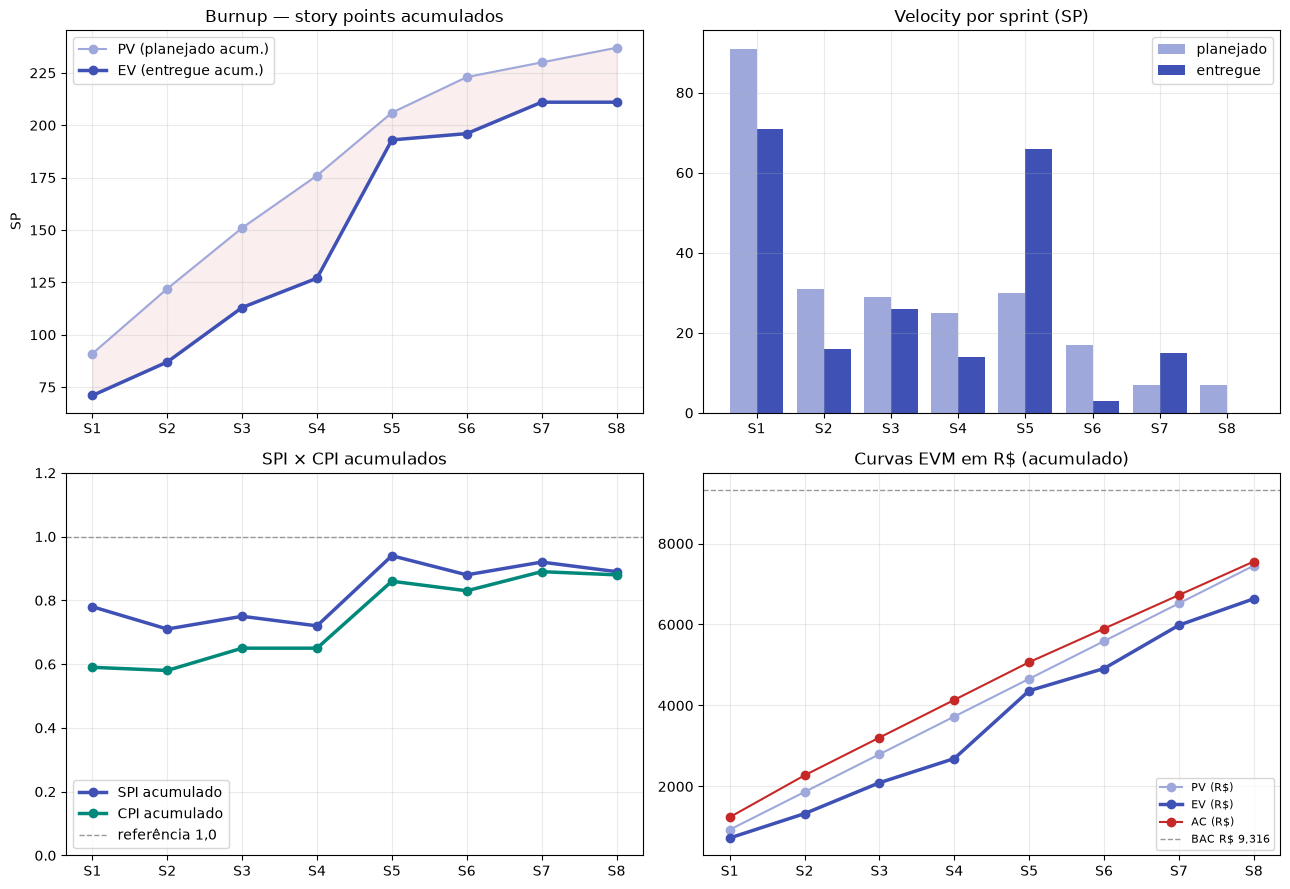

Última sprint fechada (S8): SPI=0.89 · CPI=0.88 · EAC=R$ 10,608.63 · VAC=R$ -1,292.33 (BAC R$ 9,316.30)
Previsão de ritmo: velocity mediana 15.5 SP × 2 sprints restantes = 31 SP de capacidade · backlog aberto estimado: 20 SP


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
rot = [p["sprint"] + ("*" if p["emAndamento"] else "") for p in J["evm"]]

ax = axes[0][0]
ax.plot(rot, evm["pvPts"], marker="o", color="#9fa8da", label="PV (planejado acum.)")
ax.plot(rot, evm["evPts"], marker="o", lw=2.5, color=AZUL, label="EV (entregue acum.)")
ax.fill_between(rot, evm["evPts"], evm["pvPts"], color=VERMELHO, alpha=0.08)
ax.set_title("Burnup — story points acumulados"); ax.legend(); ax.set_ylabel("SP")

ax = axes[0][1]
vel = pd.DataFrame(J["velocity"])
x = range(len(vel))
ax.bar([i - 0.2 for i in x], vel["planejado"], width=0.4, color="#9fa8da", label="planejado")
ax.bar([i + 0.2 for i in x], vel["entregue"], width=0.4, color=AZUL, label="entregue")
ax.set_xticks(list(x)); ax.set_xticklabels(vel["sprint"] + vel["emAndamento"].map({True: "*", False: ""}))
ax.set_title("Velocity por sprint (SP)"); ax.legend()

ax = axes[1][0]
ax.plot(rot, evm["spi"], marker="o", lw=2.5, color=AZUL, label="SPI acumulado")
ax.plot(rot, evm["cpi"], marker="o", lw=2.5, color="#00897b", label="CPI acumulado")
ax.axhline(1.0, color="#999", ls="--", lw=1, label="referência 1,0")
ax.set_ylim(0, 1.2); ax.set_title("SPI × CPI acumulados"); ax.legend()

ax = axes[1][1]
ax.plot(rot, evm["pvReais"], marker="o", color="#9fa8da", label="PV (R$)")
ax.plot(rot, evm["evReais"], marker="o", lw=2.5, color=AZUL, label="EV (R$)")
ax.plot(rot, evm["acReais"], marker="o", color=VERMELHO, label="AC (R$)")
ax.axhline(J["parametros"]["bac"], color="#999", ls="--", lw=1, label=f"BAC R$ {J['parametros']['bac']:,.0f}")
ax.set_title("Curvas EVM em R$ (acumulado)"); ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

ult = [p for p in J["evm"] if not p["emAndamento"]][-1]
print(f"Última sprint fechada ({ult['sprint']}): SPI={ult['spi']} · CPI={ult['cpi']} · "
      f"EAC=R$ {ult['eac']:,.2f} · VAC=R$ {ult['vac']:,.2f} (BAC R$ {J['parametros']['bac']:,.2f})")
prev = J["previsao"]
print(f"Previsão de ritmo: velocity mediana {prev['velocidadeMedianaSP']} SP × {prev['sprintsRestantes']} sprints restantes "
      f"= {prev['capacidadeRestanteSP']} SP de capacidade · backlog aberto estimado: {prev['backlogAbertoEstimadoSP']} SP")

### Interpretação — Projeto (planejado × realizado)

- **Escopo/cronograma (SPI termina em 0,89):** medido pelo registro inicial, o SPI era 0,66 — mas isso era um **artefato de medição**, não de entrega. O board tinha um grande **débito de estimativa**: ~60 SP de trabalho realmente entregue (turmas, recompensas, listas, quiz, cadastro de professor, dashboards, amizades) estava sem `estimate` e por isso não contava no EV. A equipe pontuou esses cards (sizing retrospectivo, 31 cards em duas levas) e o SPI corrigido é **0,89** — ou seja, o time entregou ~89% do que planejou; o board é que escondia isso.
- **⚠ Limitação honesta — bulk-close nas releases:** este time fecha issues em lote no fim de cada release (R1 em 27/04, R2 em 25/05). Por isso a **velocity por sprint é pouco confiável**: a S5 (que termina na R2) aparece com 66 SP entregues contra 30 planejados, porque concentrou o fechamento de trabalho feito ao longo de toda a R2 (S2–S5). A leitura correta é **cumulativa / por release**, não sprint a sprint. As duplicatas (trackers de US no Doc que espelham trabalho de código) foram **excluídas** do EV para não contar dobrado.
- **Débito de estimativa corrigido (transparência):** na coleta de 12/06, S5 media 27 SP e S6–S8 mediam ~0 SP entregues, porque vários cards entregues fecharam sem pontuação. Em 14/06 a equipe pontuou esses cards (sizing retrospectivo do esforço real) e as estimativas foram gravadas no ZenHub. Resultado medido: **S5 27 → 48 SP** e **S7 0 → 15 SP**. Não é maquiar número — é completar um registro que faltava, com a estimativa do próprio time, e está documentado (script `aplicar-estimativas.mjs`).
- **Custo (CPI ≈ 0,80):** o custo real incorrido supera levemente o valor agregado; **EAC ≈ R$ 11,6 mil contra BAC de R$ 9,3 mil (VAC ≈ −R$ 2,3 mil)**. Desvio de custo moderado e estável — a equipe efetiva (média ~9,3) ficou perto do baseline de 9.
- **SPI ≈ CPI, mas agora por um motivo real:** a equipe efetiva (média ~9,3 pessoas) acompanhou o baseline de 9, então o custo por sprint ficou perto do orçado — o gap para 1,0 é quase todo de **escopo**, não de custo. Diferente do modelo antigo, onde SPI ≡ CPI era imposto por definição (AC = orçamento da sprint). As curvas PV(R\$) e AC(R\$) aparecem separadas no gráfico para comprovar.
- **A leitura gerencial honesta:** o risco do projeto nunca foi custo — foi **gestão de escopo**. A correção do EVM torna isso visível e mensurável.
- **A S6–S8 mediam ≈ 0 SP por artefato de medição** (cards entregues sem pontuação). Após a correção do débito de estimativa, S7 passou a refletir os 15 SP realmente entregues; a S6/S8 seguem baixas porque o restante do trabalho do período veio como PRs ainda atrelados a cards sem ponto ou a issues fechadas tarde — segue como ação contínua (D7).
- **Releases:** RM1 e RM2 entregues nos marcos; para a R3 final (29/06), a capacidade restante (~3 sprints × 16 SP ≈ 48 SP) comporta o backlog aberto **estimado** (12 SP) — mas **67 issues abertas não têm estimate**, ou seja, o escopo real é desconhecido. A decisão D6 trata disso: estimar o que entra na R3 final e cortar o que exceder a capacidade.

## 4. Qualidade dos dados — análise crítica

Nenhuma análise acima vale mais do que os dados que a alimentam. Auditoria da base:

In [10]:
H = P["higiene"]
issues = pd.DataFrame([i for i in zenhub_issues["issues"] if not i["ehPr"]])
auditoria = pd.DataFrame([
    {"verificação": "Issues sem estimate", "qtd": H["semEstimate"], "% do total": round(100 * H["semEstimate"] / H["totalIssues"]), "impacto": "velocity e EVM subestimados (S6–S8)"},
    {"verificação": "Issues sem responsável", "qtd": H["semResponsavel"], "% do total": round(100 * H["semResponsavel"] / H["totalIssues"]), "impacto": "distribuição por membro parcial"},
    {"verificação": "Issues sem sprint", "qtd": H["semSprint"], "% do total": round(100 * H["semSprint"] / H["totalIssues"]), "impacto": "planejado × realizado por janela de datas"},
    {"verificação": "Fechadas em lote (12/06)", "qtd": H["fechadasEmLote1206"], "% do total": round(100 * H["fechadasEmLote1206"] / H["totalIssues"]), "impacto": "excluídas das medianas de fluxo"},
    {"verificação": "Paradas > 14 dias em etapas de trabalho", "qtd": H["paradasMais14d"], "% do total": round(100 * H["paradasMais14d"] / H["totalIssues"]), "impacto": "issues hygiene (benchmark GitHub)"},
])
auditoria

,verificação,qtd,% do total,impacto
0,Issues sem estimate,101,56,velocity e EVM subestimados (S6–S8)
1,Issues sem responsável,64,35,distribuição por membro parcial
2,Issues sem sprint,72,40,planejado × realizado por janela de datas
3,Fechadas em lote (12/06),6,3,excluídas das medianas de fluxo
4,Paradas > 14 dias em etapas de trabalho,3,2,issues hygiene (benchmark GitHub)


Outras divergências encontradas e como foram tratadas:

1. **Relatórios de sprint × ZenHub:** a S1 documenta 71 SP entregues, mas apenas 16 SP aparecem fechados *dentro da janela* da S1 no ZenHub — as issues foram fechadas em 27/04, um dia após o fim da sprint. Adotamos os relatórios publicados como plano de registro (S1–S4) e o ZenHub como fonte medida (S5+), com a coluna `fonte` explícita na tabela de sprints.
2. **`Sprint.totalPoints/completedPoints` do ZenHub** divergem da soma das issues (rollover automático de sprint conta a mesma issue duas vezes). **Rejeitamos** esses agregados prontos e recalculamos por issue × janela de datas.
3. **Repos BFF e Quiz-Service não estavam conectados ao workspace ZenHub** — suas issues entram via GitHub; os eventos de pipeline cobrem os repos conectados.
4. **Chave SonarCloud do frontend** estava documentada como `-Front`, mas a real é `-Web` — corrigida nos scripts de extração.

## 5. Decisões gerenciais baseadas em dados (≥ 5)

| # | Causa (evidência nos dados) | Análise | Decisão | Resultado esperado / observado |
|---|------------------------------|---------|---------|--------------------------------|
| **D1** (R1) | Incerteza técnica do SSO Microsoft; risco de retrabalho — SPI S1 = 0,78 com US03/US04 não entregues | Integração externa bloqueava o fluxo de professor inteiro | Cadastro local com SIAPE + aprovação do admin; SSO adiado | Fluxo de professor entregue na R2 sem retrabalho; SPI S3 = 0,90 |
| **D2** (R2) | Crescimento do domínio (questões, turmas, quiz) num único serviço | Acoplamento crescente e conflitos de merge | Arquitetura BFF + Usuario-Service + Quiz-Service | Frentes paralelas sem conflito; cobertura ≥ 85% mantida por serviço |
| **D3** (R1) | Frontend bloqueado pelo backend de auth em desenvolvimento | Dependência serializava o trabalho de 12 pessoas | Mocks controlados por `VITE_USAR_MOCKS` | Desenvolvimento paralelo; mocks desligados em produção |
| **D4** (R3) | Cobertura do Quiz-Service abaixo da meta (66% na coleta de 02/06, vs ≥ 85% dos demais) — dashboard de Produto | Repos com features novas concentram código não testado | Priorizar elevação de cobertura do Quiz-Service na R3 | Coleta de 12/06 já mostra recuperação; gate de 85% volta a valer para o repo |
| **D5** (R3) | Prontidão 0,68: ~1/3 das execuções de CI falham antes do merge | Falhas de build consomem ciclos de revisão e mascaram regressões | Rodar lint+testes localmente antes do push (hook/checklist de PR) | Elevar estabilidade de builds para ≥ 0,80 (faixa verde do Plano de Qualidade) |
| **D6** (R3) | 67 issues abertas **sem estimate** — a capacidade restante (~48 SP) só comporta o backlog *estimado* (12 SP); o escopo real da R3 é desconhecido — dashboard de Projeto | Sem estimar o que falta, qualquer compromisso de entrega final é chute; empurrar escopo não medido degradaria qualidade | Sessão de refinamento: estimar tudo que pleiteia a R3 final e **cortar o que exceder ~48 SP** (gamificação e IA além do MVP validável primeiro na fila de corte) | Escopo da apresentação final fechado com os POs e alinhado à capacidade real |
| **D7** (R3) | ~60 SP de entrega real sem estimate; SPI medido (0,66) era artefato de medição, não de entrega | Sem estimates, EVM e velocity perdem validade — o dashboard fica cego | **Executado:** equipe pontuou 31 cards entregues sem estimate (sizing retrospectivo, em duas levas); IA aplicou no ZenHub e excluiu duplicatas. **Adiante:** estimate obrigatório ao puxar para Sprint Backlog | SPI corrigido de 0,66 → **0,89**, com a estimativa real do time (não auto-preenchimento) |

## 6. Uso crítico de IA na construção e interpretação

**Ferramenta:** Claude Code (modelo Fable 5), em sessão supervisionada por Miguel Moreira. Papel da IA: engenharia de extração de dados, modelagem dos indicadores e geração de dashboards/notebook. Papel humano: decisões de modelo, validação dos números contra as fontes e aceite/rejeição das propostas.

**Aceito (com verificação):**
- Extração via APIs (ZenHub GraphQL + REST de eventos, GitHub, SonarCloud `component_tree`) com dados brutos versionados para auditoria.
- **Correção do modelo EVM**: a IA diagnosticou que AC = BAC por sprint forçava SPI ≡ CPI e propôs o AgileEVM cumulativo com AC pela equipe efetiva — aceito após conferência manual dos custos (R$ 1.034,46 da S2 e R$ 931,65 das S3–S5 reproduzidos pela fórmula do Plano de Custos).
- Cálculo dos limites WIP pela Lei de Little a partir dos eventos reais do board.

**Rejeitado / corrigido pelo time:**
- **O modelo de EVM passou por iterações até ficar fiel ao exemplo da disciplina.** Uma versão intermediária definiu o cronograma por `PPC = sprints decorridas / 10` (tempo) enquanto o escopo da S1 sozinho era ~38% do total planejado — isso fazia o SPI **explodir nas primeiras sprints** (S1 = 7,8) e o gráfico cortava esses valores. O time rejeitou: o enquadramento do anexo do professor é em story points (`SPI = SP entregues / SP planejados`), o que dá uma série estável (SPI termina em 0,89). Exemplo concreto de por que output de IA não se aceita sem verificar contra a fonte (aqui, o próprio exemplo do professor).
- **Quitação do débito de estimativa (humano decide, IA executa).** A IA identificou os cards entregues sem pontuação e listou-os; a **equipe** decidiu os story points (sizing retrospectivo); a IA aplicou no ZenHub e recoletou. Rejeitou-se explicitamente o atalho de "preencher 3 ou 5 SP automáticos para inflar o EVM" — isso seria fabricar dado e é trivialmente detectável (timestamps em lote). A linha aceita: completar o registro com a estimativa real do time, de forma documentada.
- **Atribuição por data de entrega real.** Os cards #82/#66/#67 (S7) foram reabertos por engano por um membro durante a revisão do board; ao recoletar ao vivo, o `closed_at` viraria 14/06 (S8). Rejeitou-se usar o estado ao vivo transitório; usou-se o **snapshot de coleta de 12/06**, em que esses cards estavam fechados na S7 (PRs mergeados em 02/06) — a data em que o valor realmente shipou.
- Usar `totalPoints/completedPoints` prontos do ZenHub (dupla contagem no rollover — recalculado por issue).
- Usar o lead time de *todas* as issues (a limpeza de board de 12/06 distorcia as medianas — criado o recorte "fluxo de código").
- Chave SonarCloud `-Front` sugerida pela documentação interna (real: `-Web`).

**Limites:** os textos de interpretação foram revisados pelo time; as decisões D1–D7 são do time (a IA organizou evidências). Prompts e iterações registrados no `MD_Template.md` do semestre.

## 7. Conclusão

O semestre fecha com **produto saudável** (Qualidade do Produto 0,86; 0 bugs abertos no SonarCloud; cobertura ponderada ~90%), **processo com fluxo curto e estável** (cycle time ~2 dias; WIP dentro dos limites da Lei de Little) e **projeto com lição clara de higiene de dados**: o EVM ágil mostra entrega de ~89% do planejado (SPI ≈ 0,89) a um custo levemente acima do orçado (CPI ≈ 0,88). O número só ficou fiel depois de quitar o débito de estimativa — o board mal mantido escondia ~60 SP de entrega real — e excluir as duplicatas; a velocity por sprint deve ser lida com o caveat do bulk-close nas releases. A resposta gerencial (D6/D7) é manter a disciplina de estimar e **fechar cards na hora** (não em lote no fim da release), para o EVM não voltar a mentir contra o próprio time.

**Artefatos desta entrega:** [Dashboard Produto](https://fga-eps-mds.github.io/2026-1-AnatoQuizUp-Doc/dashboards/produto.html) · [Dashboard Processo](https://fga-eps-mds.github.io/2026-1-AnatoQuizUp-Doc/dashboards/processo.html) · [Dashboard Projeto](https://fga-eps-mds.github.io/2026-1-AnatoQuizUp-Doc/dashboards/projeto.html) · [Canvas Analytics](https://fga-eps-mds.github.io/2026-1-AnatoQuizUp-Doc/dashboards/canvas.html) · dados brutos e scripts em `DA-R3/`.